In [1]:
import PriceRatioExperiment as PRE

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import random

In [2]:
N = 100
num = 11

prod_values = np.logspace(-1, 1, num)
labor_coeffs = 1.0/prod_values

In [3]:
T = 500

n = len(labor_coeffs)
n = n*n

l_ratio_df = []
p_ratio_df = []
p_ratio_std_df = []
c1_df = []

for l1 in labor_coeffs:
    
    print(l1)
    
    for l2 in labor_coeffs:
        
        try:
    
            c1 = np.random.uniform(0, 1.0/l1)
            c2 = 1.0/l2*(1.0 - l1*c1)

            pre = PRE.PriceRatioExperiment(N, l1, l2, c1, c2)
            
            pre.N1 = 50
            pre.N2 = 50

            Me_df, Qe_df, ntries_df, p_df = pre.run_experiment(T)

            p_ratio     = np.nanmean(p_df[:,0]/p_df[:,1])
            p_ratio_std = np.nanstd(p_df[:,0]/p_df[:,1])

            
        except:
            
            print('Fail for')
            print(l1, l2)
            print()
            
            p_ratio = np.nan
            p_ratio_std = np.nan
        
        l_ratio_df.append(l1/l2)
        p_ratio_df.append(p_ratio)
        p_ratio_std_df.append(p_ratio_std)
        c1_df.append(c1)

        
        
        

10.0


C:\Users\Alex\Documents\Research\EconoABM\EconoNet\2024-01-28_Testing_Price_Ratios\PriceRatioExperiment.py:96: RuntimeWarning: invalid value encountered in divide
  self.p_df = self.Me_df/self.Qe_df


6.3095734448019325
3.9810717055349727
2.5118864315095797
1.5848931924611132


C:\Users\Alex\AppData\Local\Temp\ipykernel_2176\3204479075.py:27: RuntimeWarning: Mean of empty slice
  p_ratio     = np.nanmean(p_df[:,0]/p_df[:,1])
C:\Users\Alex\anaconda3\envs\pytorchgame3.10\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


1.0
0.630957344480193
0.3981071705534971
0.25118864315095796
0.15848931924611132
0.1


In [ ]:
len(pre.agent_list)
pre.N

Text(0, 0.5, 'Price Ratios ($p_1/p_2$)')

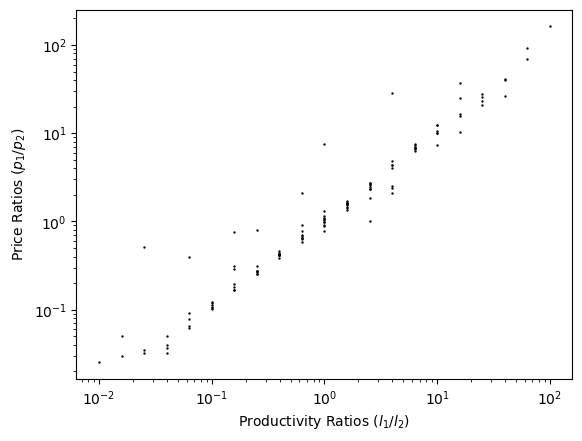

In [4]:
plt.scatter(l_ratio_df, p_ratio_df, s = 0.5, c='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Productivity Ratios ($l_1/l_2$)')
plt.ylabel('Price Ratios ($p_1/p_2$)')

Text(0, 0.5, 'Price Ratio Standard Deviations')

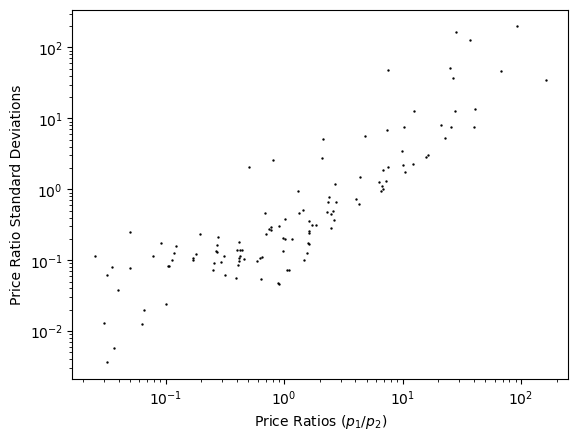

In [5]:
plt.scatter(p_ratio_df, p_ratio_std_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel('Price Ratio Standard Deviations')

Text(0, 0.5, '$\\bar{c}_1$')

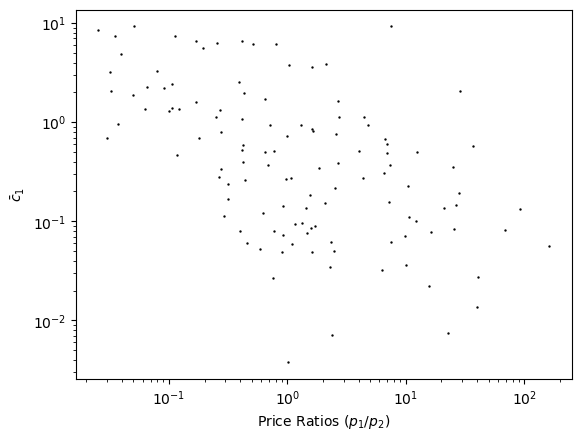

In [6]:
plt.scatter(p_ratio_df, c1_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel(r'$\bar{c}_1$')